In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import re
import os.path as op
from typing import Tuple, Iterator
# EEG utilities
import mne
# BIDS utilities
from util.io.bids import DataSink
from bids import BIDSLayout
# PLV functions
from util.io.ffr import read_epochs
# from util.io.plv import *
from scipy.stats import shapiro, mannwhitneyu
from arch.bootstrap import IIDBootstrap

SyntaxError: invalid syntax (448874355.py, line 12)

### Load PLVs

In [ ]:
fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')

plvs = pd.DataFrame()
for fpath in fpaths:
    plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

plvs

# PLVs by accuracy

In [ ]:
# Functions for computing effects sizes for mann-whitney U
def Z_from_U(n1, n2, U):
    mean_U = n1 * n2 / 2
    sd_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    
    z = (U - mean_U) / sd_U
    return z

def cohens_r(n1, n2, z):
    N = n1 + n2
    r = z / np.sqrt(N)
    return r

In [ ]:
# Regenerate null, but in a dataframe
np.random.seed(42)
draws = 1000
subs = 1000
null = np.array([])

for i in range(subs):
    plvs = list()
    for j in range(draws):
        # Draw random phases from a uniform distribution
        phases = np.random.uniform(low = 0, high = 2*np.pi, size = 400)
        plv = np.abs(np.mean(np.exp(1j * phases)))
        plvs.append(plv)
    mean_plv = np.mean(plvs)
    null = np.append(null, mean_plv)


# Get 95% CI
CI90 = np.percentile(null, 90)
print(f'90% CI: {CI90}')
CI95 = np.percentile(null, 95)
print(f'95% CI: {CI95}')

# Create null dataframe
null = pd.DataFrame({
    'subj': 'null',
    'accuracy_group': 'null',
    'plv': null,
    'stim_freq': 'null'
})

In [ ]:
fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')
plvs = pd.DataFrame()
for fpath in fpaths:
    plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

In [ ]:
# Add accuracy group to dataframe
accuracy = pd.read_csv('accuracy.csv', index_col = 0)
accuracy = accuracy.rename(columns = {'subject': 'subj', 'score_group': 'accuracy_group'})
plvs = plvs.rename(columns = {'sub': 'subj'})
plvs = plvs.merge(accuracy, left_on = ["subj"], right_on = ["subj"])
plvs

In [12]:
# # Readjust median split
# med = np.median(plvs.accuracy)
# print(med)
# plvs.loc[plvs['accuracy'] > med, 'accuracy_group'] = 'high'
# plvs.loc[plvs['accuracy'] < med, 'accuracy_group'] = 'low'

In [11]:
palette_tab10 = sns.color_palette("tab10", 10)

In [ ]:
plvs_130 = plvs[plvs.stim_freq == 130]
plvs_130 = plvs_130.groupby(['subj', 'accuracy_group', 'stim_freq'], as_index=False)['plv'].mean()
plvs_130 = pd.concat([plvs_130, null])
plvs_130

### 130 Hz

In [25]:
# Plot with null
plvs_130 = plvs[plvs.stim_freq == 130]
plvs_130 = plvs_130.groupby(['subj', 'accuracy'], as_index=False)['plv'].mean()
plvs_130 = pd.concat([plvs_130, null])
plvs_130['accuracy'] = plvs_130['accuracy'].replace({'low': 'low accuracy', 'high': 'high accuracy'})
ax = sns.stripplot(data=plvs_130, hue = 'accuracy', y = 'accuracy', x = "plv", palette={"low accuracy": palette_tab10[0], "high accuracy": palette_tab10[1], "null": "grey"}, alpha = 0.7)
plt.xlim(0, 0.55)

groups = plvs_130["accuracy"].unique().tolist()
colors = [palette_tab10[0], palette_tab10[1], 'grey']

for i, (g, color) in enumerate(zip(groups, colors)):
    med = plvs_130.loc[plvs_130["accuracy"] == g, "plv"].median()
    ax.plot([med, med], [i-0.2, i+0.2], color=color, lw=2)

plt.savefig("../figs/PLV-130-hz-scatter.png", dpi = 300)

# Values
plvs_130.groupby(['accuracy'], as_index=False)['plv'].mean()
descriptives = plvs_130.groupby(['accuracy'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_130.groupby(['accuracy'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_130.groupby(['accuracy'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

# Tests
high = plvs_130[plvs_130.accuracy == 'high accuracy']
low = plvs_130[plvs_130.accuracy == 'low accuracy']

bs = IIDBootstrap(null.plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("null BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(low.plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(high.plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("high BCa 95% CI:", ci[0], ci[1])

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv)
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

print('compare to null')
print(np.sum([null.plv > np.median(low.plv)][0]))
print(np.sum([null.plv > np.median(high.plv)][0]))

AttributeError: 'list' object has no attribute 'stim_freq'

In [45]:
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

print(np.sum(plvs_130.plv[plvs_130.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'low'].tolist()[0]))
print(np.sum(plvs_130.plv[plvs_130.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'high'].tolist()[0]))

low BCa 95% CI: [0.04464784] [0.04823136]
high BCa 95% CI: [0.04602568] [0.05045459]
  accuracy_group       med        Q1        Q3       IQR
0           high  0.048555  0.045816  0.051226  0.005410
1            low  0.045933  0.044663  0.049842  0.005179
2           null  0.044272  0.043786  0.044775  0.000989
14
0


**Tests**

In [46]:
high = plvs_130[plvs_130.accuracy_group == 'high']
low = plvs_130[plvs_130.accuracy_group == 'low']
null = plvs_130[plvs_130.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.8883525133132935, pvalue=0.014656975865364075)
ShapiroResult(statistic=0.7237424254417419, pvalue=0.00010814608685905114)
ShapiroResult(statistic=0.9964521527290344, pvalue=0.023049497976899147)
compare groups
high vs null: u = 22300.0, p = 6.355970069162389e-15, r = 0.24102531844408437
low vs null: u = 22300.0, p = 1.223166267838532e-05, r = 0.31552706253508644
high vs low: u = 289.0, p = 0.03845173520934555, r = 0.2749034236223175


### 200 Hz

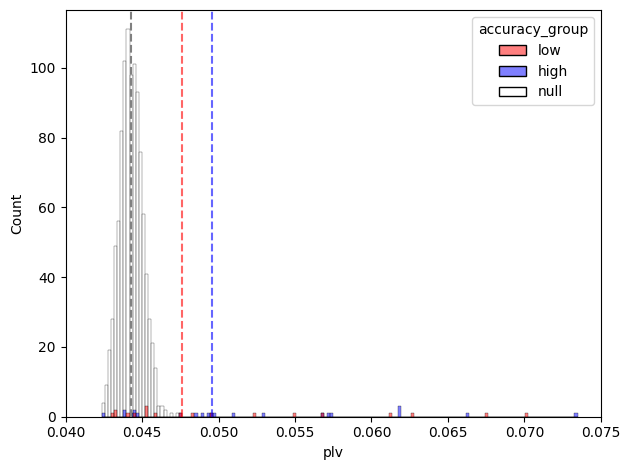

In [47]:
plvs_200 = plvs[plvs.stim_freq == 200]
plvs_200 = plvs_200.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_200 = pd.concat([plvs_200, null])
sns.histplot(plvs_200, x = "plv", hue = "accuracy_group", palette={"high": "blue", "low": "red", "null": "white"})
plt.axvline(np.median(plvs_200[plvs_200.accuracy_group == 'high'].plv), color='blue', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_200[plvs_200.accuracy_group == 'low'].plv), color='red', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_200[plvs_200.accuracy_group == 'null'].plv), color='grey', linestyle='--')
plt.tight_layout()
plt.xlim(0.04, 0.075)
plt.savefig("../figs/PLV-200-hz.png", dpi = 300)

**Stats**

In [48]:
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

print(np.sum(plvs_200.plv[plvs_200.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'low'].tolist()[0]))
print(np.sum(plvs_200.plv[plvs_200.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'high'].tolist()[0]))

low BCa 95% CI: [0.0444599] [0.0524093]
high BCa 95% CI: [0.04472554] [0.05671206]
  accuracy_group       med        Q1        Q3       IQR
0           high  0.049542  0.044664  0.057260  0.012597
1            low  0.047590  0.044870  0.055964  0.011094
2           null  0.044272  0.043786  0.044775  0.000989
0
0


**Tests**

In [49]:
high = plvs_200[plvs_200.accuracy_group == 'high']
low = plvs_200[plvs_200.accuracy_group == 'low']
null = plvs_200[plvs_200.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.9000139832496643, pvalue=0.025296542793512344)
ShapiroResult(statistic=0.8375034332275391, pvalue=0.004228716250509024)
ShapiroResult(statistic=0.9964521527290344, pvalue=0.023049497976899147)
compare groups
high vs null: u = 19060.0, p = 3.407652669038444e-08, r = 0.16871772291085907
low vs null: u = 19060.0, p = 9.26691730660956e-06, r = 0.2356592748308927
high vs low: u = 243.0, p = 0.2720931928031376, r = 0.09553381388293304


### 280 Hz

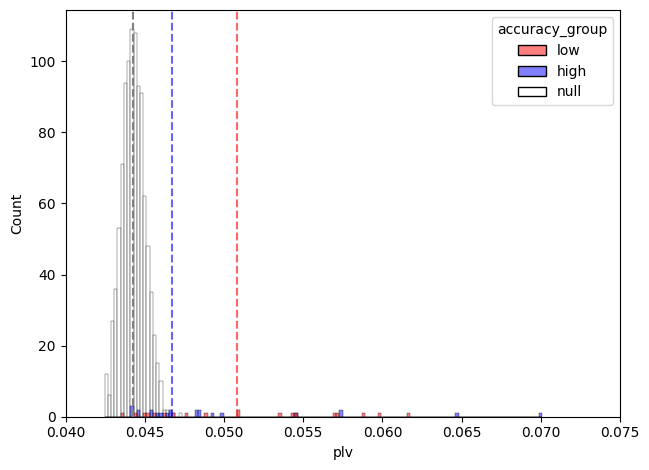

In [50]:
plvs_280 = plvs[plvs.stim_freq == 280]
plvs_280 = plvs_280.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_280 = pd.concat([plvs_280, null])
sns.histplot(plvs_280, x = "plv", hue = "accuracy_group", palette={"high": "blue", "low": "red", "null": "white"})
plt.axvline(np.median(plvs_280[plvs_280.accuracy_group == 'high'].plv), color='blue', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_280[plvs_280.accuracy_group == 'low'].plv), color='red', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_280[plvs_280.accuracy_group == 'null'].plv), color='grey', linestyle='--')
plt.tight_layout()
plt.xlim(0.04, 0.075)
plt.savefig("../figs/PLV-280-hz.png", dpi = 300)

**Stats**

In [51]:
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
print(descriptives)

print(np.sum(plvs_280.plv[plvs_280.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'low'].tolist()[0]))
print(np.sum(plvs_280.plv[plvs_280.accuracy_group == 'null'] > descriptives.med[descriptives.accuracy_group == 'high'].tolist()[0]))

low BCa 95% CI: [0.04559498] [0.05430516]
high BCa 95% CI: [0.04541733] [0.04851041]
  accuracy_group       med        Q1        Q3       IQR
0           high  0.046706  0.045386  0.049600  0.004213
1            low  0.050819  0.045939  0.055743  0.009804
2           null  0.044272  0.043786  0.044775  0.000989
0
2


**Tests**

In [52]:
high = plvs_280[plvs_280.accuracy_group == 'high']
low = plvs_280[plvs_280.accuracy_group == 'low']
null = plvs_280[plvs_280.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.7507975697517395, pvalue=6.893932004459202e-05)
ShapiroResult(statistic=0.9240527153015137, pvalue=0.13448750972747803)
ShapiroResult(statistic=0.9964521527290344, pvalue=0.023049497976899147)
compare groups
high vs null: u = 20529.0, p = 5.797347614210471e-11, r = 0.2015016296510776
low vs null: u = 20529.0, p = 2.511344104607818e-10, r = 0.27187093536714596
high vs low: u = 177.0, p = 0.8557380856128591, r = -0.16182258269966207


### Save PLVs for MLM

In [20]:
np.random.seed(42)

BIDS_ROOT = '../data/bids'
DERIV_ROOT = '../data/bids/derivatives'
layout = BIDSLayout(BIDS_ROOT, derivatives = True)
subs = layout.get_subjects(scope = 'preprocess_ffr')
subs.sort(key = int)

stim_freqs = [130, 200, 280]

# Bootstrapping params
draws = 1000
n_obs = 400 # determined using find-n-epochs-per-conditions.ipynb

# Load the data from one subject
df = pd.DataFrame()
for sub in subs:

    # read FFR epochs
    epochs = read_epochs(BIDS_ROOT, sub, 'forFFR')

    # Crop
    epochs = epochs.crop(tmin = 0)

    # Add condition labels
    epochs = add_metadata(epochs, condition_mapping)
    
    for stim_freq in stim_freqs:
        for target in stim_freqs:
            plvs = np.array([])
            for i in range(draws):
                
                # Select data by condition
                data_array = epochs[f"(stim == {stim_freq}) & (target == {target})"].get_data(copy = True)
                data_array = np.squeeze(data_array)
                
                # Draw n random observations
                draw = data_array[np.random.randint(1, np.shape(data_array)[0], n_obs), :]
            
                # Constants for computing FFT
                N = np.shape(draw)[1] # time points
                fs = 5000 # sampling rate
                T = 1/fs # msec of each time point
            
                # Compute FFTs of each signal
                ffts = np.fft.fft(draw)
                    
                # # Extract the frequency bin of interest (e.g., approximating 10 Hz)
                freqs = np.fft.fftfreq(N, d = T) 
                idx = np.abs(freqs - stim_freq).argmin()
            
                # Extract the phase information
                phases = np.angle(ffts[:, idx])
                
                # Compute the PLV as the average value for the draw
                plv = np.abs(np.mean(np.exp(1j * phases)))
                plvs = np.append(plvs, plv)
            
            # Average over all draws
            plvs = np.mean(plvs) 
            
            # Create dataframe
            condition_plvs = pd.DataFrame({
                'sub': [sub],
                'stimulus': [stim_freq],
                'target': [target],
                'plv': [plvs]
            })
            df = pd.concat([df, condition_plvs], ignore_index = True)

df.to_csv('plvs.csv', index = False)

/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/bids/layout/validation.py:124: UserWarning: The PipelineDescription field was superseded by GeneratedBy in BIDS 1.4.0. You can use ``pybids upgrade`` to update your derivative dataset.
  warnings.warn("The PipelineDescription field was superseded "
/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/bids/layout/validation.py:124: UserWarning: The PipelineDescription field was superseded by GeneratedBy in BIDS 1.4.0. You can use ``pybids upgrade`` to update your derivative dataset.
  warnings.warn("The PipelineDescription field was superseded "


['/project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-3/sub-3_task-pitch_run-1_desc-forFFR_epo.fif.gz']
Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-3/sub-3_task-pitch_run-1_desc-forFFR_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     400.00 ms
        0 CTF compensation matrices available
Not setting metadata
5195 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
5195 matching events found
Applying baseline correction (mode: mean)
Adding metadata with 2 columns


/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/bids/layout/validation.py:124: UserWarning: The PipelineDescription field was superseded by GeneratedBy in BIDS 1.4.0. You can use ``pybids upgrade`` to update your derivative dataset.
  warnings.warn("The PipelineDescription field was superseded "


['/project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-4/sub-4_task-pitch_run-1_desc-forFFR_epo.fif.gz']
Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-4/sub-4_task-pitch_run-1_desc-forFFR_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     400.00 ms
        0 CTF compensation matrices available
Not setting metadata
1332 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
1332 matching events found
Applying baseline correction (mode: mean)
Adding metadata with 2 columns


/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/bids/layout/validation.py:124: UserWarning: The PipelineDescription field was superseded by GeneratedBy in BIDS 1.4.0. You can use ``pybids upgrade`` to update your derivative dataset.
  warnings.warn("The PipelineDescription field was superseded "


...

['/project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-43/sub-43_task-pitch_run-1_desc-forFFR_epo.fif.gz']
Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-43/sub-43_task-pitch_run-1_desc-forFFR_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     400.00 ms
        0 CTF compensation matrices available
Not setting metadata
3774 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
3774 matching events found
Applying baseline correction (mode: mean)
Adding metadata with 2 columns


/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/bids/layout/validation.py:124: UserWarning: The PipelineDescription field was superseded by GeneratedBy in BIDS 1.4.0. You can use ``pybids upgrade`` to update your derivative dataset.
  warnings.warn("The PipelineDescription field was superseded "


['/project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-44/sub-44_task-pitch_run-1_desc-forFFR_epo.fif.gz']
Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-44/sub-44_task-pitch_run-1_desc-forFFR_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     400.00 ms
        0 CTF compensation matrices available
Not setting metadata
3823 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
3823 matching events found
Applying baseline correction (mode: mean)
Adding metadata with 2 columns


/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/bids/layout/validation.py:124: UserWarning: The PipelineDescription field was superseded by GeneratedBy in BIDS 1.4.0. You can use ``pybids upgrade`` to update your derivative dataset.
  warnings.warn("The PipelineDescription field was superseded "


['/project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-45/sub-45_task-pitch_run-1_desc-forFFR_epo.fif.gz']
Reading /project/hcn1/Letty/pitch_tracking_attention/analysis/../data/bids/derivatives/preprocess_ffr/sub-45/sub-45_task-pitch_run-1_desc-forFFR_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     400.00 ms
        0 CTF compensation matrices available
Not setting metadata
3851 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
3851 matching events found
Applying baseline correction (mode: mean)
Adding metadata with 2 columns


In [41]:
power_f0 = pd.read_csv('power_f0.csv')
power_f0 = power_f0.rename(columns = {'subject': 'sub'})
df = df.astype({'sub': int}) 
power_f0 = power_f0.merge(df, left_on = ["sub", "stimulus", "target"], right_on = ["sub", "stimulus", "target"])
power_f0.to_csv('plv_and_power_f0.csv', index = False)

In [42]:
power_f0

,sub,target,stimulus,frequency,power,accuracy,group,plv
0,3,130,130,129.460581,2.126778,0.804233,low,0.067186
1,3,200,130,129.460581,7.821449,0.804233,low,0.064202
2,3,280,130,129.460581,6.387437,0.804233,low,0.088707
3,4,130,130,129.460581,3.763498,0.961423,high,0.072699
4,4,200,130,129.460581,4.520233,0.961423,high,0.109270
...,...,...,...,...,...,...,...,...
373,44,200,280,278.838174,6.061416,0.902753,low,0.047470
374,44,280,280,278.838174,5.798800,0.902753,low,0.080376
375,45,130,280,278.838174,-0.807070,0.979403,high,0.060068
376,45,200,280,278.838174,1.511245,0.979403,high,0.051455
